In [1]:
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv(
    "../data/bronze/openfootball/bronze_matches.csv"
)

goals = pd.read_csv(
    "../data/bronze/openfootball/bronze_goals.csv"
)

team_stats = pd.read_csv(
    "../data/bronze/openfootball/bronze_team_match_stats.csv"
)

In [2]:
matches.shape

(1069, 29)

In [3]:
goals.shape

(2720, 11)

In [4]:
team_stats.shape

(1928, 14)

In [5]:
country_mapping = {
    "West Germany": "Germany",
    "Soviet Union": "Russia",
    "Czechoslovakia": "Czech Republic",
    "Yugoslavia": "Serbia"
}

In [6]:
team_stats["team_normalized"] = (
    team_stats["team"]
    .replace(country_mapping)
)

In [7]:
games_by_year = (
    matches
    .groupby("year")
    .size()
    .sort_index()
)

games_by_year

year
1930     18
1934     17
1938     19
1950     22
1954     26
1958     35
1962     32
1966     32
1970     32
1974     38
1978     38
1982     52
1986     52
1990     52
1994     52
1998     64
2002     64
2006     64
2010     64
2014     64
2018     64
2022     64
2026    104
dtype: int64

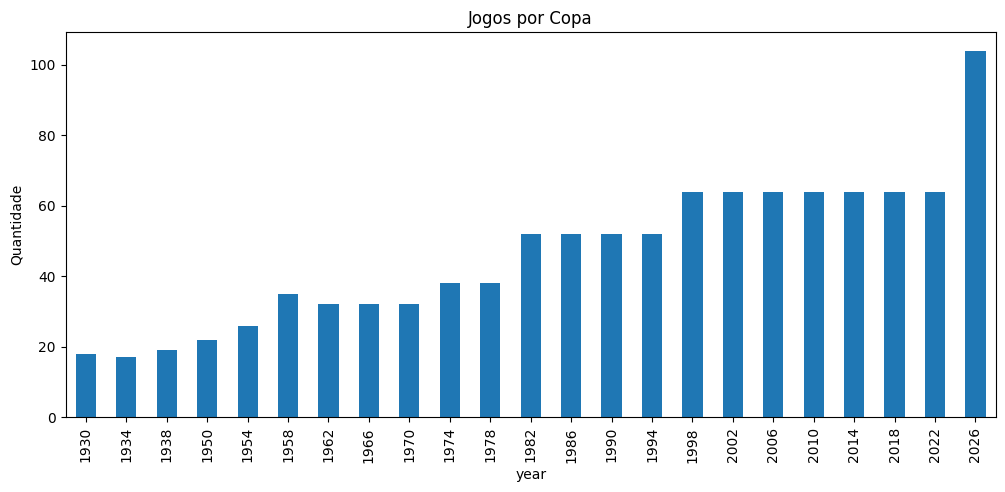

In [8]:
games_by_year.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Jogos por Copa")
plt.ylabel("Quantidade")
plt.show()

In [9]:
avg_goals = (
    matches
    .groupby("year")["total_goals_final"]
    .mean()
)

avg_goals

year
1930    3.888889
1934    4.117647
1938    4.666667
1950    4.000000
1954    5.384615
1958    3.600000
1962    2.781250
1966    2.781250
1970    2.968750
1974    2.552632
1978    2.684211
1982    2.807692
1986    2.538462
1990    2.211538
1994    2.711538
1998    2.671875
2002    2.515625
2006    2.296875
2010    2.265625
2014    2.671875
2018    2.640625
2022    2.687500
2026         NaN
Name: total_goals_final, dtype: float64

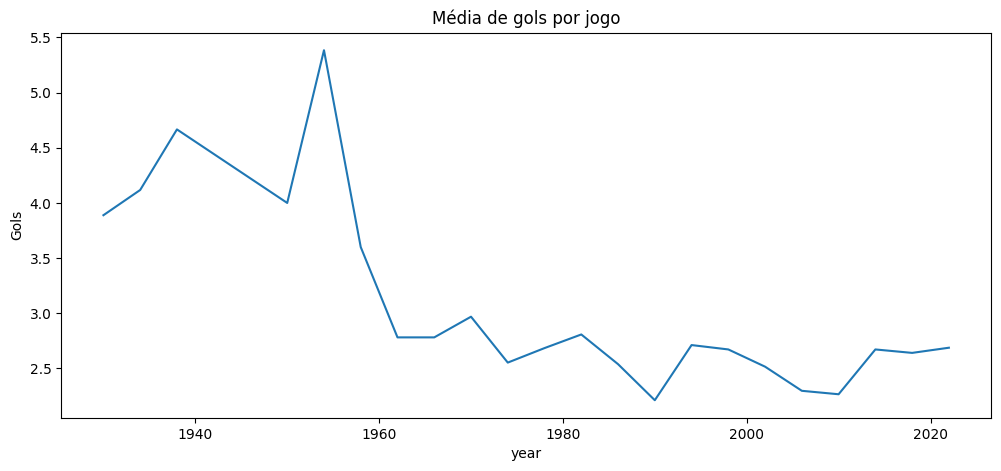

In [10]:
avg_goals.plot(
    figsize=(12,5)
)

plt.title("Média de gols por jogo")
plt.ylabel("Gols")
plt.show()

In [16]:
top_scoring_teams = (
    team_stats
    .groupby("team_normalized")["goals_for"]
    .sum()
    .sort_values(ascending=False)
)

top_scoring_teams.head(20)

team_normalized
Brazil            237
Germany           232
Argentina         152
France            136
Italy             128
Spain             108
England           104
Netherlands        96
Uruguay            89
Hungary            87
Sweden             80
Russia             77
Belgium            69
Serbia             69
Mexico             62
Portugal           61
Switzerland        55
Poland             49
Czech Republic     47
Austria            43
Name: goals_for, dtype: int64

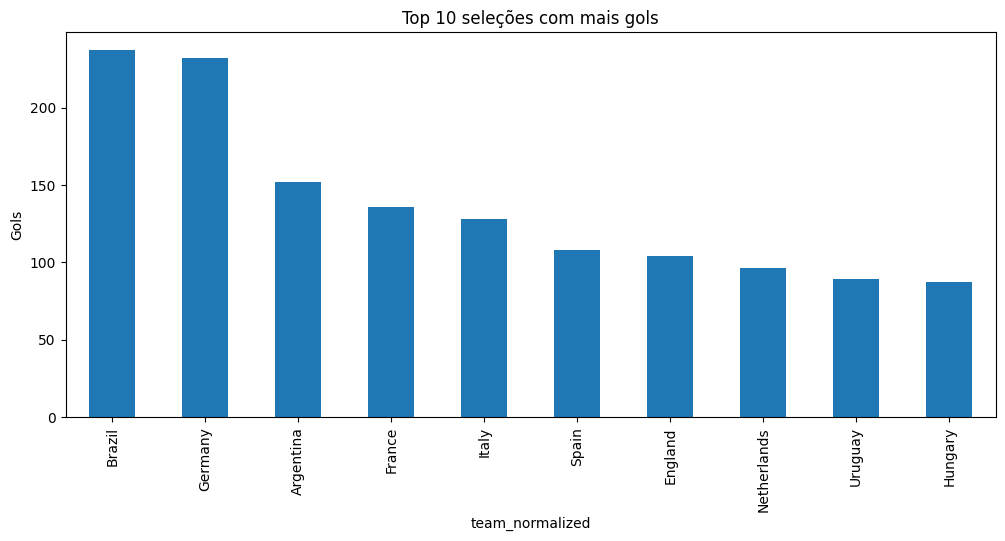

In [17]:
top_scoring_teams.head(10).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 seleções com mais gols")
plt.ylabel("Gols")
plt.show()

In [21]:
goal_difference = (
    team_stats
    .groupby("team_normalized")["goal_difference"]
    .sum()
    .sort_values(ascending=False)
)

goal_difference.head(20)

team_normalized
Brazil          129
Germany         102
Argentina        51
Italy            51
France           51
Netherlands      44
England          36
Spain            33
Hungary          30
Russia           23
Portugal         20
Uruguay          13
Croatia          10
Serbia            8
Sweden            7
Turkey            3
Colombia          2
Denmark           2
East Germany      0
Ireland           0
Name: goal_difference, dtype: int64

In [24]:
top_scoring_teams = (
    team_stats
    .groupby("team_normalized")["goals_for"]
    .sum()
    .sort_values(ascending=False)
)

top_scoring_teams.head(10)

team_normalized
Brazil         237
Germany        232
Argentina      152
France         136
Italy          128
Spain          108
England        104
Netherlands     96
Uruguay         89
Hungary         87
Name: goals_for, dtype: int64

In [25]:
print(team_stats[["team_normalized"]].drop_duplicates())

         team_normalized
0                 France
1                 Mexico
2              Argentina
4                  Chile
12                Serbia
...                  ...
1479            Slovakia
1605  Bosnia-Herzegovina
1709             Iceland
1745              Panama
1800               Qatar

[82 rows x 1 columns]


In [28]:
matches.head(3)

,match_id,match_num,year,cup_name,round,date,time,team1,team2,team1_score_ft,...,team2_score_final,total_goals_final,team1_score_p,team2_score_p,total_goals_p,group,ground,status,has_score,has_goals_events
0,1930_1,NaN,1930,World Cup 1930,Matchday 1,1930-07-13,NaN,France,Mexico,4.0,...,1.0,5.0,NaN,NaN,NaN,Group 1,"Estadio Pocitos, Montevideo",played,True,True
1,1930_2,NaN,1930,World Cup 1930,Matchday 3,1930-07-15,NaN,Argentina,France,1.0,...,0.0,1.0,NaN,NaN,NaN,Group 1,"Estadio Parque Central, Montevideo",played,True,True
2,1930_3,NaN,1930,World Cup 1930,Matchday 4,1930-07-16,NaN,Chile,Mexico,3.0,...,0.0,3.0,NaN,NaN,NaN,Group 1,"Estadio Parque Central, Montevideo",played,True,True


In [29]:
goals.head(3)

,match_id,year,team,opponent,player_name,minute,offset,penalty,owngoal,goal_side,goal_source
0,1930_1,1930,France,Mexico,L. Laurent,19.0,NaN,False,False,team1,event
1,1930_1,1930,France,Mexico,Langiller,40.0,NaN,False,False,team1,event
2,1930_1,1930,France,Mexico,Maschinot,43.0,NaN,False,False,team1,event


In [30]:
team_stats.head(3)

,match_id,year,cup_name,round,date,team,opponent,goals_for,goals_against,goal_difference,is_winner,is_draw,is_loser,match_played,team_normalized
0,1930_1,1930,World Cup 1930,Matchday 1,1930-07-13,France,Mexico,4,1,3,True,False,False,True,France
1,1930_1,1930,World Cup 1930,Matchday 1,1930-07-13,Mexico,France,1,4,-3,False,False,True,True,Mexico
2,1930_2,1930,World Cup 1930,Matchday 3,1930-07-15,Argentina,France,1,0,1,True,False,False,True,Argentina
